In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import itertools

In [2]:
data = pd.read_csv('training_wildfire_weather_2020_2024.csv')

In [3]:
target = ["size (acres)", "fire_spread (acres/day)", "duration"]
predictor = [c for c in data.columns if c not in target + ["startdateseason"]] # filtering out startdate season

In [4]:
target

['size (acres)', 'fire_spread (acres/day)', 'duration']

In [5]:
predictor

['u10', 'v10', 'd2m', 't2m', 'msl', 'sp', 'lai_hv', 'lai_lv', 'tp', 'ssr']

In [6]:
data_reshape = (data[predictor].melt(var_name="Predictor", value_name="Value"))

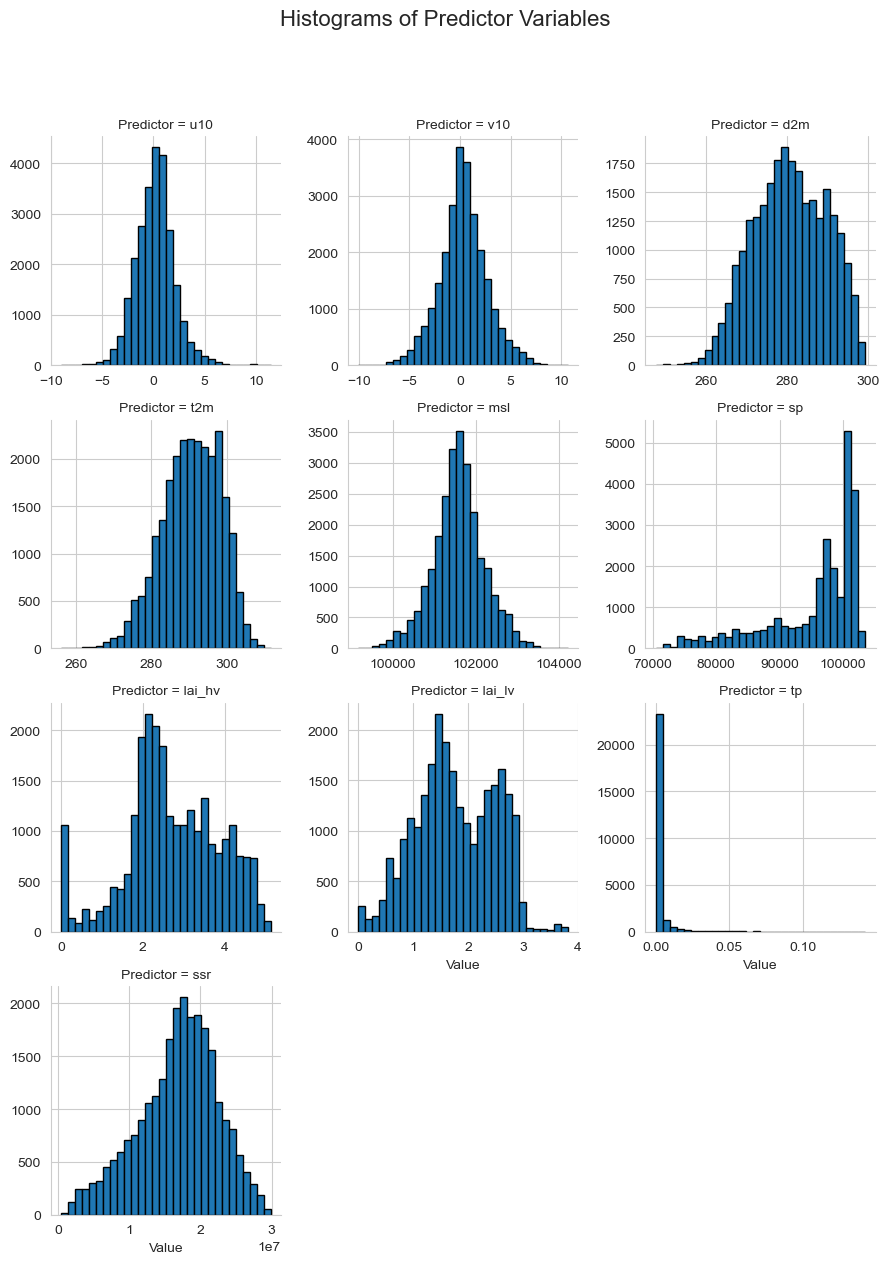

In [7]:
sns.set_style("whitegrid")
g = sns.FacetGrid(data_reshape, col="Predictor", col_wrap = 3, sharex=False, sharey=False, height=3)
g.map(plt.hist, "Value", bins=30, edgecolor="black")

g.fig.suptitle("Histograms of Predictor Variables", y=1.05, fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
data_clean = data[predictor].dropna()

In [9]:
# sns.pairplot(data_clean, corner=True)
# plt.suptitle("Scatterplot Matrix of Predictors", y=1.02)
# plt.show()

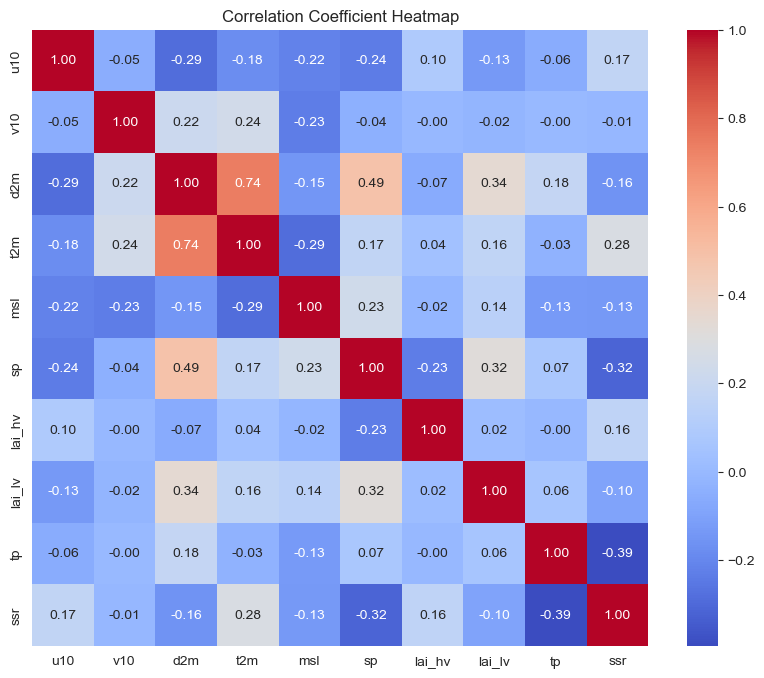

In [10]:
corr = data_clean.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Coefficient Heatmap")
plt.show()


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_clean)

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = predictor
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

print("\nVariance Inflation Factors (VIF):")
print(vif_data)


Variance Inflation Factors (VIF):
  Feature       VIF
0     u10  1.208410
1     v10  1.132025
2     d2m  4.398851
3     t2m  3.840730
4     msl  1.391428
5      sp  1.752117
6  lai_hv  1.091107
7  lai_lv  1.222737
8      tp  1.277445
9     ssr  1.848599


In [15]:
predictorCol = data[predictor]
summaryData = predictorCol.describe().T

In [18]:
iqr_vals = summaryData['75%'] - summaryData['25%']

In [20]:
mode_vals = predictorCol.mode().iloc[0]

In [21]:
summaryStats = summaryData.assign(
    mode=mode_vals,
    IQR=iqr_vals
)[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'mode', 'IQR']] 

In [22]:
summaryStats

,count,mean,std,min,25%,50%,75%,max,mode,IQR
u10,25665.0,1.279174e-01,1.846168e+00,-9.022443,-1.060984e+00,1.707613e-01,1.194915e+00,1.145855e+01,1.706125e+00,2.255899e+00
v10,25665.0,3.353808e-01,2.346150e+00,-10.041690,-1.027696e+00,2.903366e-01,1.700784e+00,1.067323e+01,5.800953e-01,2.728480e+00
d2m,25665.0,2.807379e+02,8.869830e+00,247.640150,2.741858e+02,2.806599e+02,2.878542e+02,2.991970e+02,2.929719e+02,1.366846e+01
t2m,25665.0,2.905085e+02,7.651042e+00,256.153400,2.853465e+02,2.909638e+02,2.965313e+02,3.115817e+02,3.023431e+02,1.118481e+01
msl,25665.0,1.015851e+05,6.151140e+02,99178.340000,1.012295e+05,1.015826e+05,1.019358e+05,1.042124e+05,1.014261e+05,7.062500e+02
sp,25665.0,9.539834e+04,7.373725e+03,70434.540000,9.188504e+04,9.797153e+04,1.009504e+05,1.035182e+05,1.006220e+05,9.065374e+03
lai_hv,25665.0,2.719941e+00,1.144792e+00,0.000000,2.033249e+00,2.594070e+00,3.555176e+00,5.127843e+00,0.000000e+00,1.521927e+00
lai_lv,25665.0,1.764027e+00,7.165466e-01,0.000000,1.263196e+00,1.687912e+00,2.391085e+00,3.818481e+00,0.000000e+00,1.127889e+00
tp,25665.0,1.565008e-03,4.644073e-03,0.000000,0.000000e+00,2.837181e-05,7.922649e-04,1.421039e-01,0.000000e+00,7.922649e-04
ssr,25665.0,1.682424e+07,5.559238e+06,457728.000000,1.335069e+07,1.740526e+07,2.065802e+07,2.985043e+07,1.623316e+07,7.307334e+06


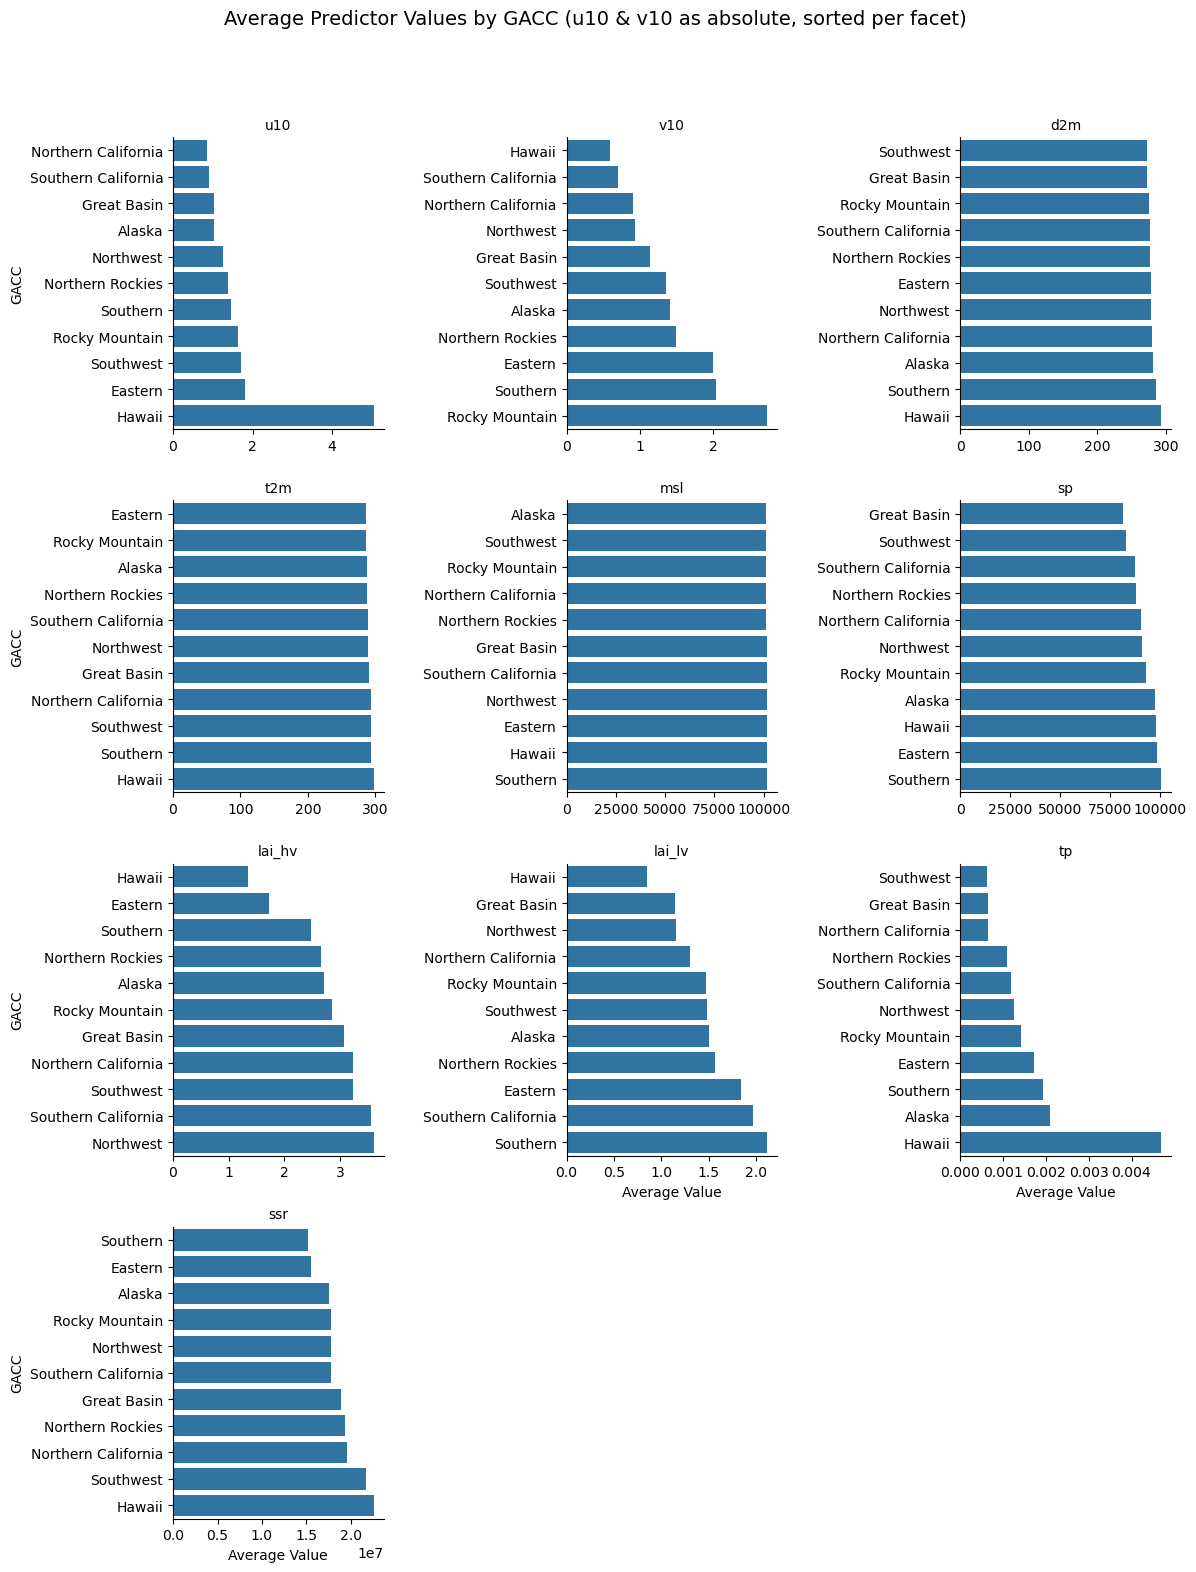

In [16]:
# Load the data
df = pd.read_csv('../data/processed_data/Wildfire_Weather_2020_2024_with_gacc.csv')

# Clean GACC names
df['gacc'] = df['gacc'].str.replace(
    r'\s*(Interagency Coordination Center|Geographic Area Coordination Center|Area Coordination Center|Coordination Center|Area)$',
    '', regex=True).str.strip()

# Absolute values for u10, v10
df['u10'] = df['u10'].abs()
df['v10'] = df['v10'].abs()

# Predictor variables
predictors = ['u10', 'v10', 'd2m', 't2m', 'msl', 'sp', 'lai_hv', 'lai_lv', 'tp', 'ssr']

# Group by GACC and calculate means
grouped = df.groupby('gacc')[predictors].mean().reset_index()

# Melt into long format
melted = grouped.melt(id_vars='gacc', var_name='predictor', value_name='avg_value')

# Create the FacetGrid with independent y-axes
g = sns.FacetGrid(melted, col="predictor", col_wrap=3, sharex=False, sharey=False, height=4)

# Sorted horizontal bar plot per facet
def sorted_barplot(data, **kwargs):
    data_sorted = data.sort_values("avg_value", ascending=True)
    sns.barplot(
        data=data_sorted,
        y="gacc",
        x="avg_value",
        order=data_sorted["gacc"],
        orient="h",
        **kwargs
    )

# Map to each facet
g.map_dataframe(sorted_barplot)

# Labels and layout
g.set_axis_labels("Average Value", "GACC")
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Average Predictor Values by GACC (u10 & v10 as absolute, sorted per facet)", fontsize=14)

plt.show()
